In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings("ignore")

import os
for dirname, _, filenames in os.walk('/kaggle/input/weather-data2000-2023'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/weather-data2000-2023/South_Africa_weather_data.csv
/kaggle/input/weather-data2000-2023/weather_data_top100.csv
/kaggle/input/weather-data2000-2023/Argentina_weather_data.csv
/kaggle/input/weather-data2000-2023/Vietnam_weather_data.csv
/kaggle/input/weather-data2000-2023/Russia_weather_data.csv
/kaggle/input/weather-data2000-2023/India_weather_data.csv
/kaggle/input/weather-data2000-2023/United_States_weather_data.csv
/kaggle/input/weather-data2000-2023/Italy_weather_data.csv
/kaggle/input/weather-data2000-2023/Philippines_weather_data.csv
/kaggle/input/weather-data2000-2023/Thailand_weather_data.csv
/kaggle/input/weather-data2000-2023/Turkey_weather_data.csv
/kaggle/input/weather-data2000-2023/Pakistan_weather_data.csv
/kaggle/input/weather-data2000-2023/Brazil_weather_data.csv
/kaggle/input/weather-data2000-2023/United_Kingdom_weather_data.csv
/kaggle/input/weather-data2000-2023/Myanmar_weather_data.csv
/kaggle/input/weather-data2000-2023/Tanzania_weather_data.csv
/kagg

In [2]:
df = pd.read_csv('/kaggle/input/weather-data2000-2023/India_weather_data.csv')

In [3]:
df.head(5)

,Country,Date,Temp_Max,Temp_Min,Temp_Mean,Precipitation_Sum,Windspeed_Max,Windgusts_Max,Sunshine_Duration
0,India,01-01-2000,27.3,12.9,20.0,0.0,9.0,22.0,35850.03
1,India,02-01-2000,26.8,12.8,19.7,0.0,9.8,24.8,35884.66
2,India,03-01-2000,26.4,13.0,19.6,0.0,9.4,19.8,35920.25
3,India,04-01-2000,26.2,13.4,19.6,0.0,9.8,20.2,35880.49
4,India,05-01-2000,26.3,12.6,19.2,0.0,9.8,21.2,35918.76


In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Temp_Max,8766.0,32.858157,4.968256,19.7,29.400,31.30,35.900,46.90
Temp_Min,8766.0,22.423488,4.872109,9.2,18.625,23.50,25.200,34.80
Temp_Mean,8766.0,27.422485,4.622524,15.8,24.300,26.80,29.700,40.10
Precipitation_Sum,8766.0,3.359354,10.352523,0.0,0.000,0.00,1.200,216.30
Windspeed_Max,8766.0,13.117488,4.495779,4.4,9.600,12.00,15.900,35.90
Windgusts_Max,8766.0,28.876968,8.972592,12.6,22.000,27.00,34.600,78.10
Sunshine_Duration,8766.0,34420.454265,10439.139096,0.0,35554.525,37312.72,40219.725,44419.17


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def eda_visuals(df, corr_method='spearman'):
    
    # Select numerical and categorical columns
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns

    # Color palette
    palette = sns.color_palette("husl", len(numerical_cols))

    # --Boxplots (Outliers)--
    plt.figure(figsize=(25, 18))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(6, 6, i)
        sns.boxplot(y=df[col], color=palette[i-1])
        plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

    # --Distributions--
    plt.figure(figsize=(25, 15))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(6, 6, i)
        sns.histplot(df[col], kde=True, color=palette[i-1], bins=30)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

    # --Pie Charts for categorical data--
    if len(categorical_cols) > 0:
        plt.figure(figsize=(18, 12))
        for i, col in enumerate(categorical_cols, 1):
            plt.subplot(3, 3, i)
            df[col].value_counts().plot.pie(
                autopct='%1.1f%%',
                startangle=90,
                cmap='tab20'
            )
            plt.title(f'Pie Chart of {col}')
            plt.ylabel('')
        plt.tight_layout()
        plt.show()

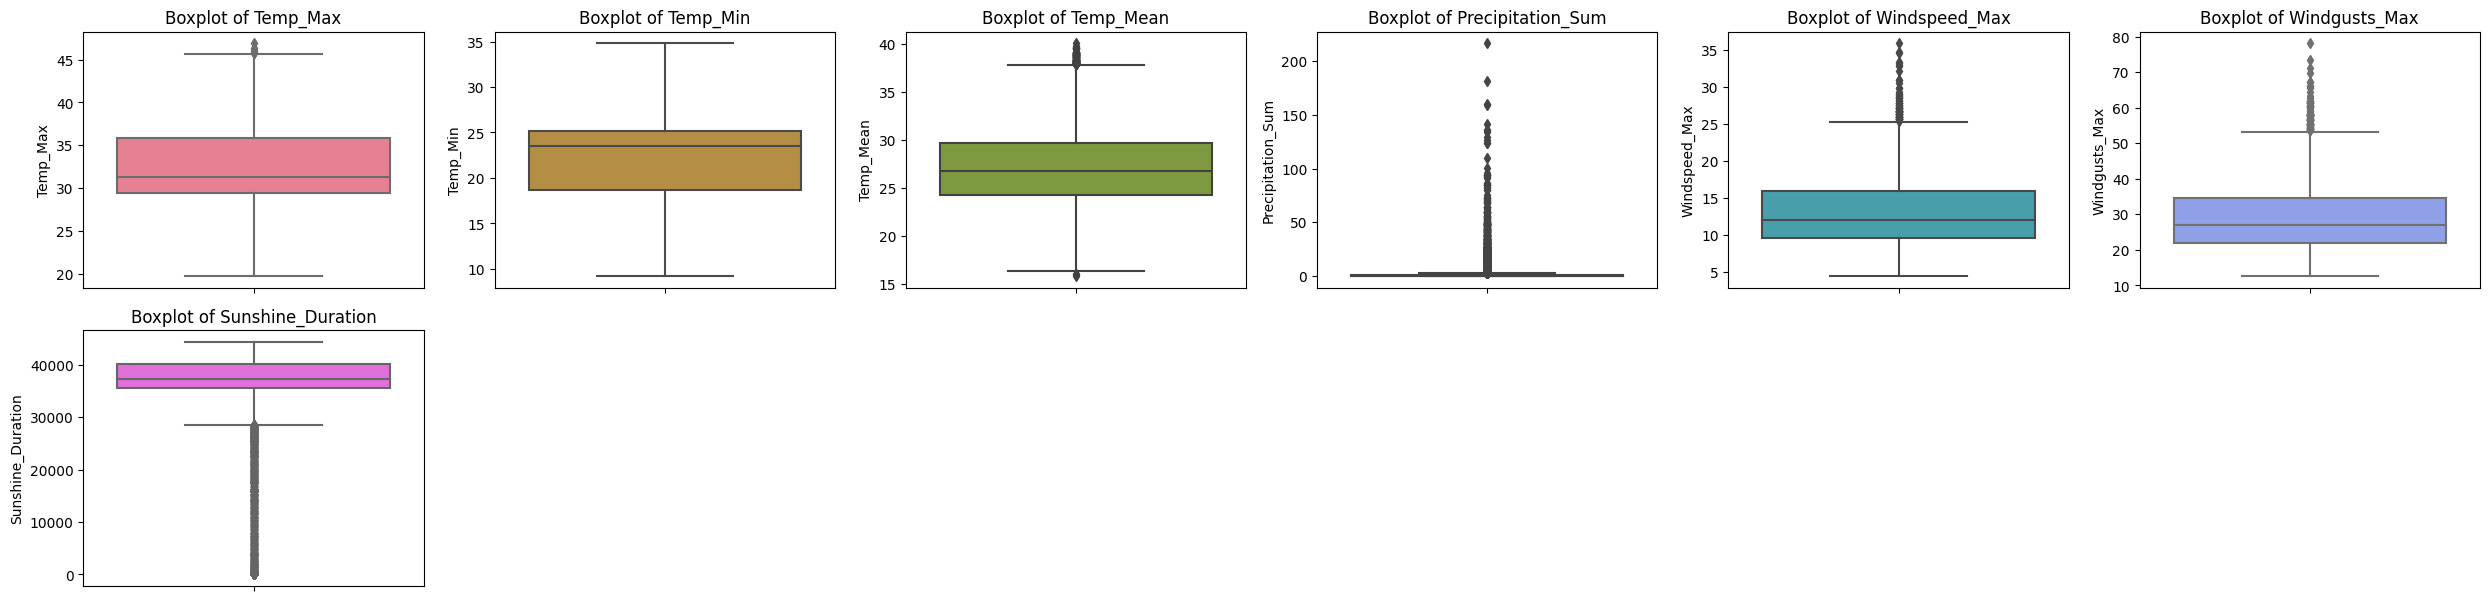

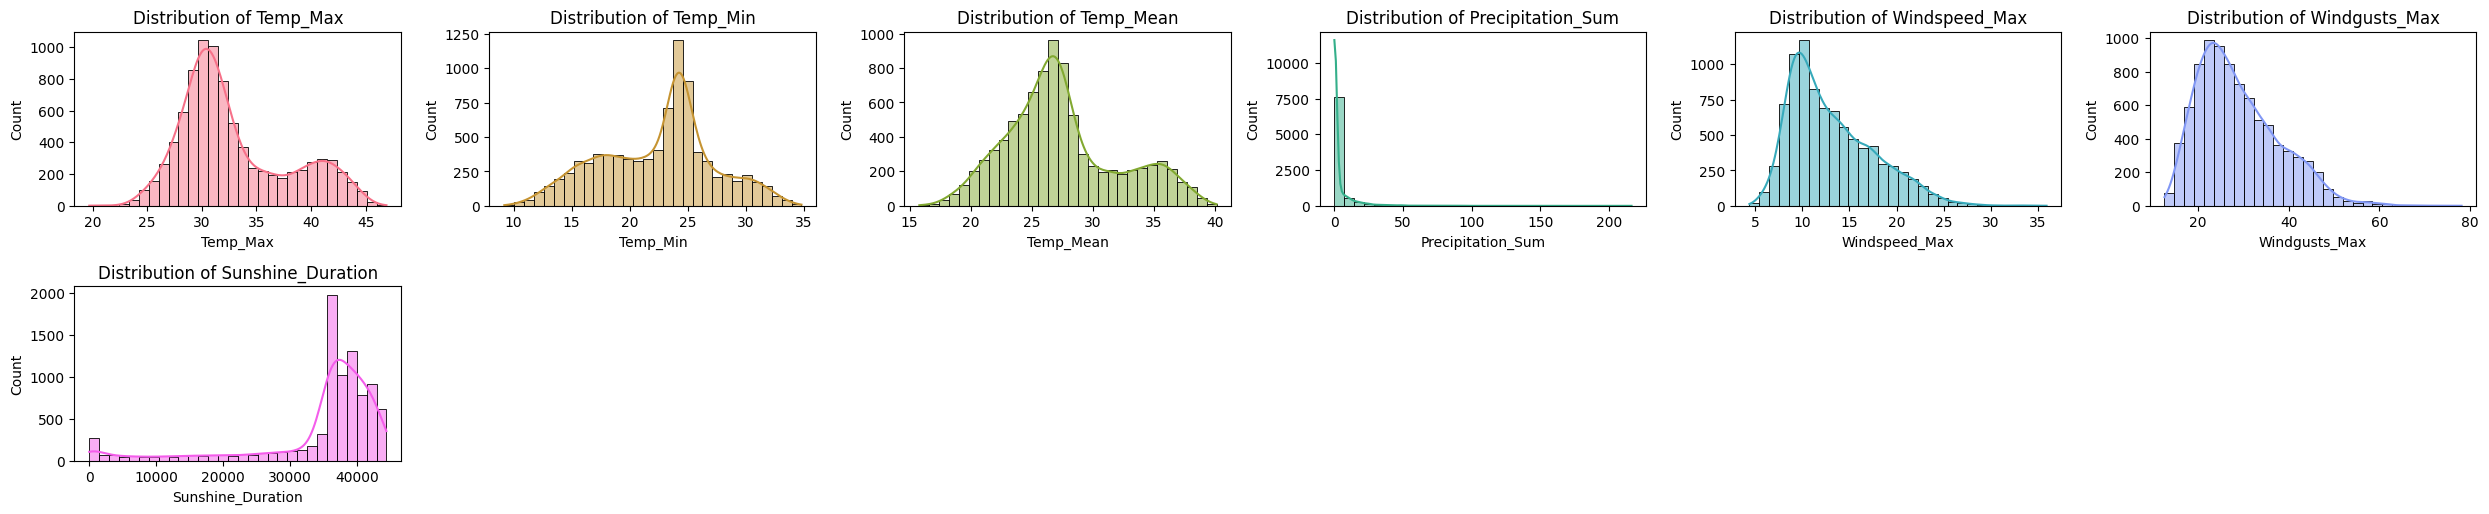

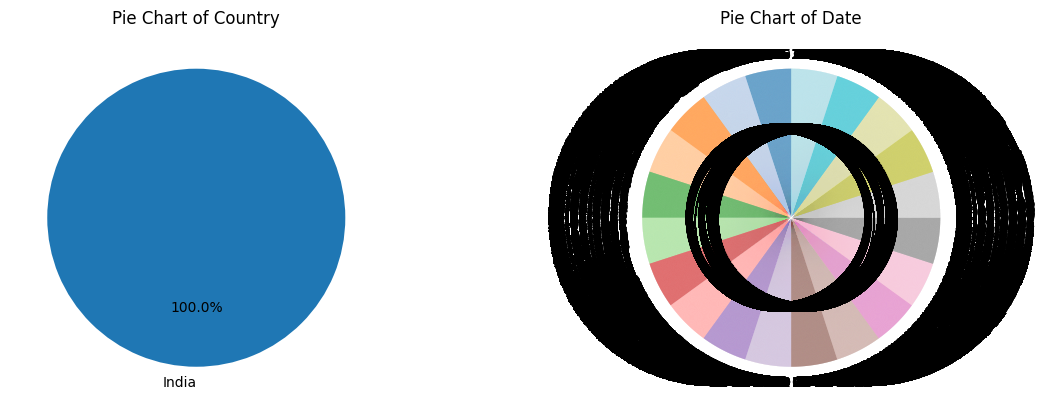

In [6]:
eda_visuals(df)


🔎 BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8766 entries, 0 to 8765
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            8766 non-null   object 
 1   Date               8766 non-null   object 
 2   Temp_Max           8766 non-null   float64
 3   Temp_Min           8766 non-null   float64
 4   Temp_Mean          8766 non-null   float64
 5   Precipitation_Sum  8766 non-null   float64
 6   Windspeed_Max      8766 non-null   float64
 7   Windgusts_Max      8766 non-null   float64
 8   Sunshine_Duration  8766 non-null   float64
dtypes: float64(7), object(2)
memory usage: 616.5+ KB
None

Shape: (8766, 9)

First 5 rows:
   Country        Date  Temp_Max  Temp_Min  Temp_Mean  Precipitation_Sum  \
0   India  01-01-2000      27.3      12.9       20.0                0.0   
1   India  02-01-2000      26.8      12.8       19.7                0.0   
2   India  03-01-2000      26.4   

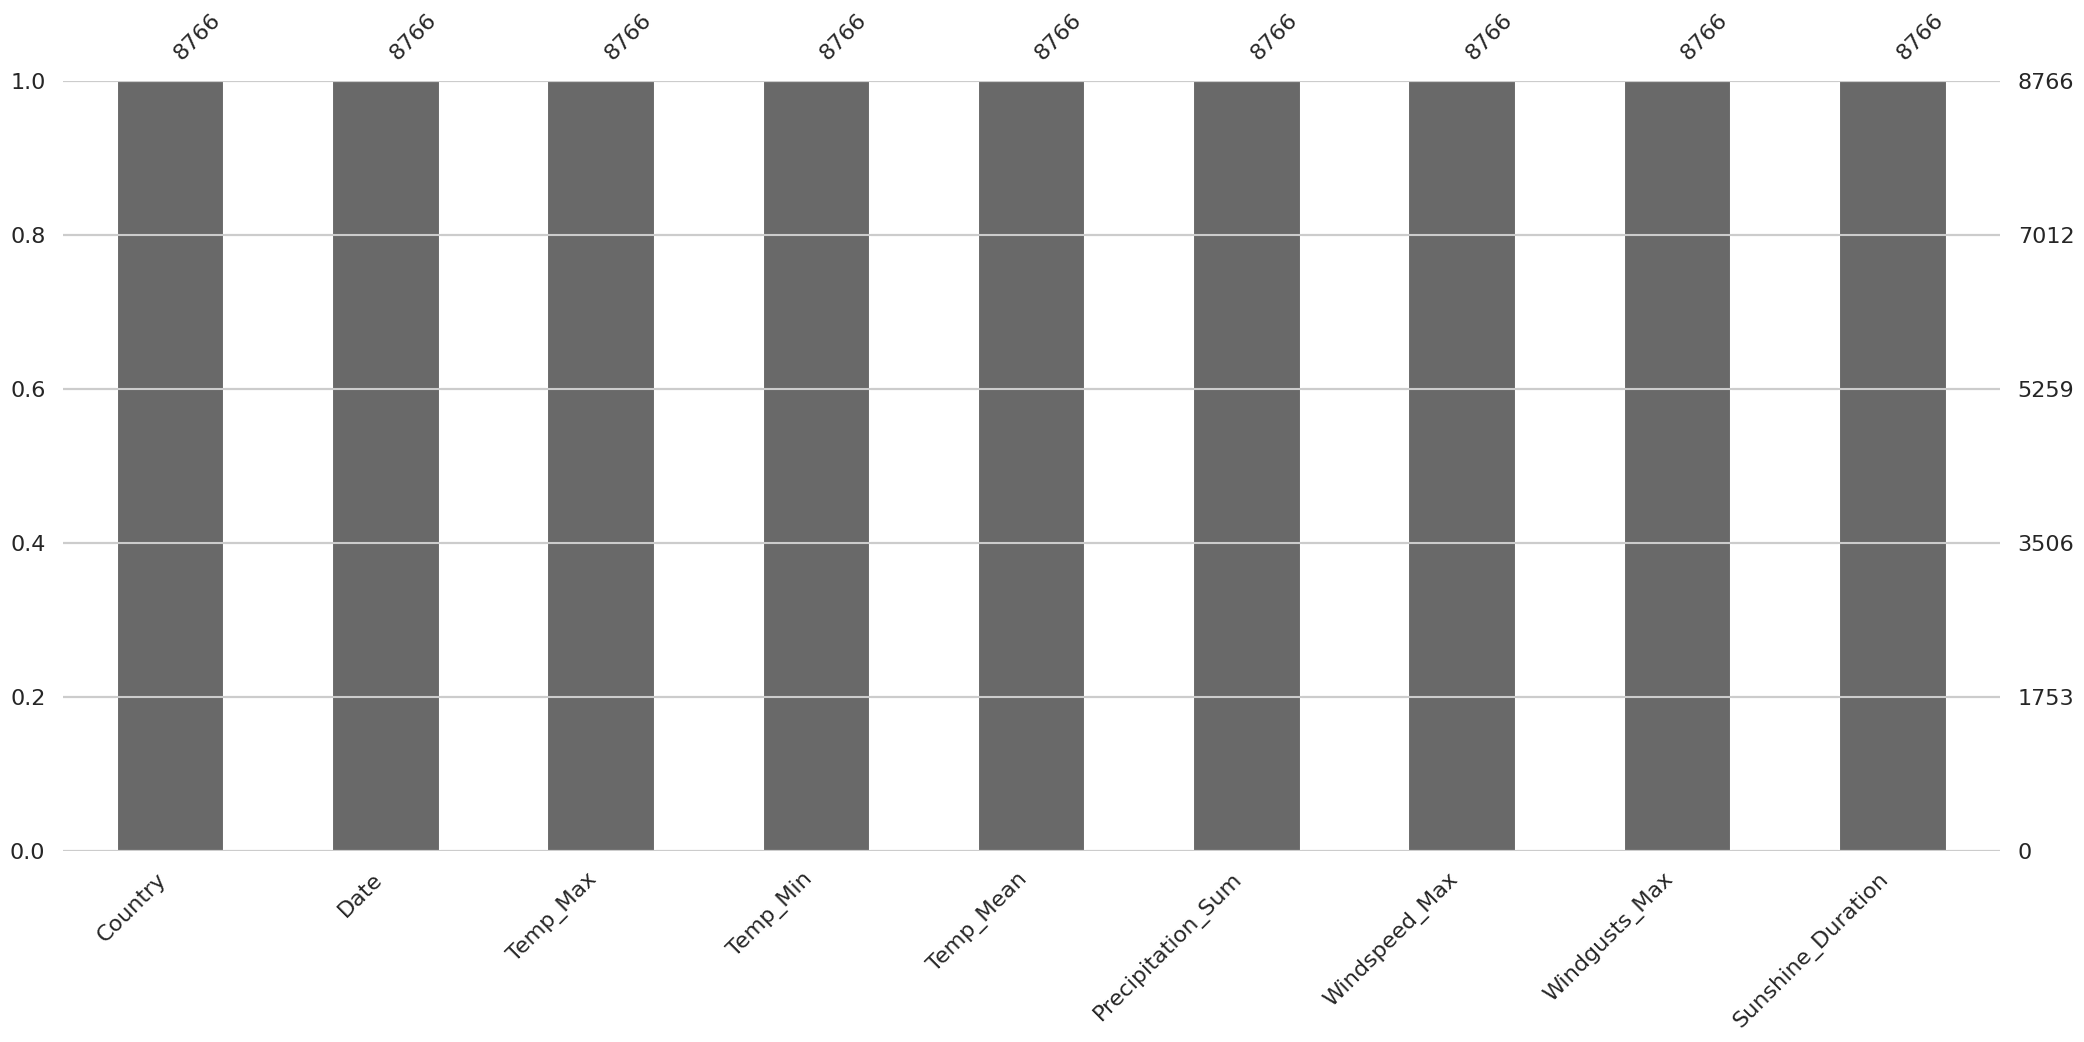


📊 Numerical summary:
                     count          mean           std   min        25%  \
Temp_Max           8766.0     32.858157      4.968256  19.7     29.400   
Temp_Min           8766.0     22.423488      4.872109   9.2     18.625   
Temp_Mean          8766.0     27.422485      4.622524  15.8     24.300   
Precipitation_Sum  8766.0      3.359354     10.352523   0.0      0.000   
Windspeed_Max      8766.0     13.117488      4.495779   4.4      9.600   
Windgusts_Max      8766.0     28.876968      8.972592  12.6     22.000   
Sunshine_Duration  8766.0  34420.454265  10439.139096   0.0  35554.525   

                        50%        75%       max  
Temp_Max              31.30     35.900     46.90  
Temp_Min              23.50     25.200     34.80  
Temp_Mean             26.80     29.700     40.10  
Precipitation_Sum      0.00      1.200    216.30  
Windspeed_Max         12.00     15.900     35.90  
Windgusts_Max         27.00     34.600     78.10  
Sunshine_Duration  37312.72

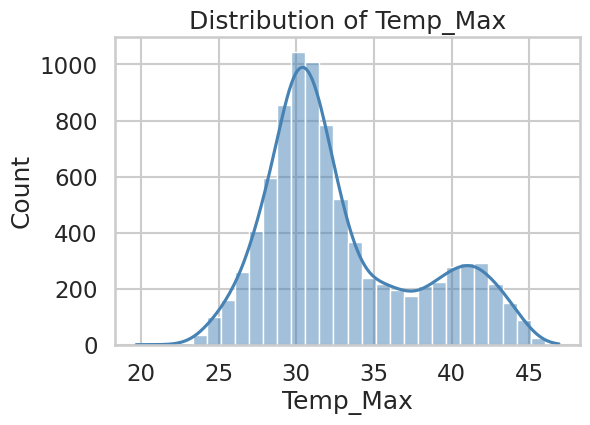

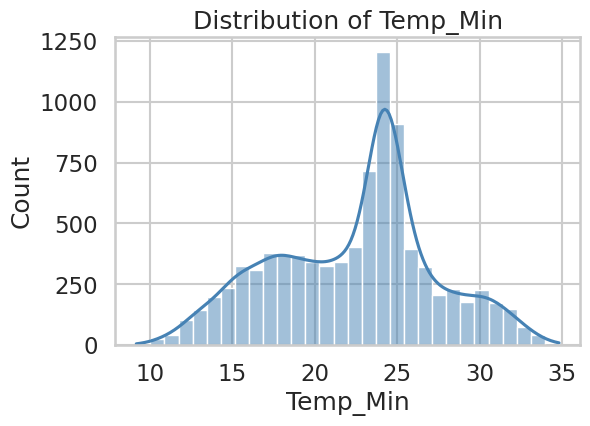

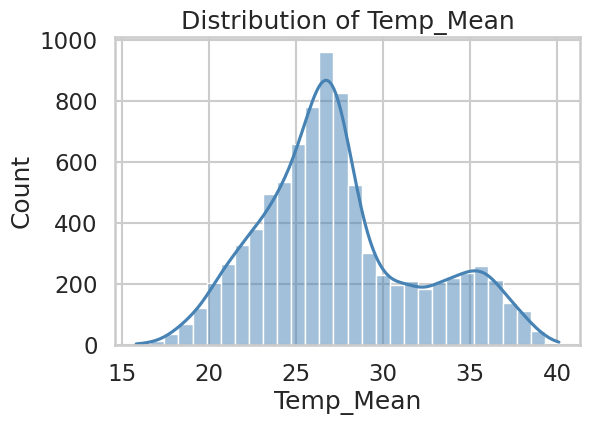

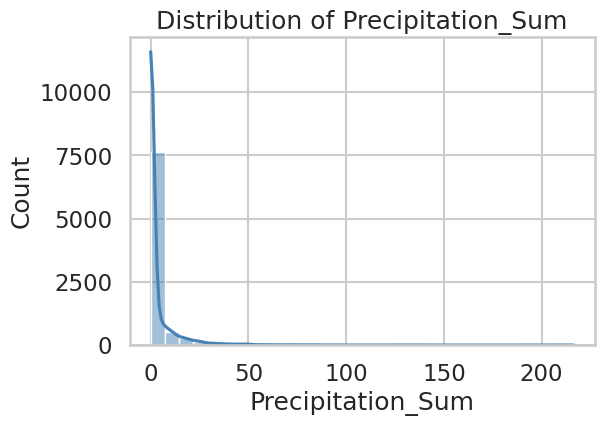

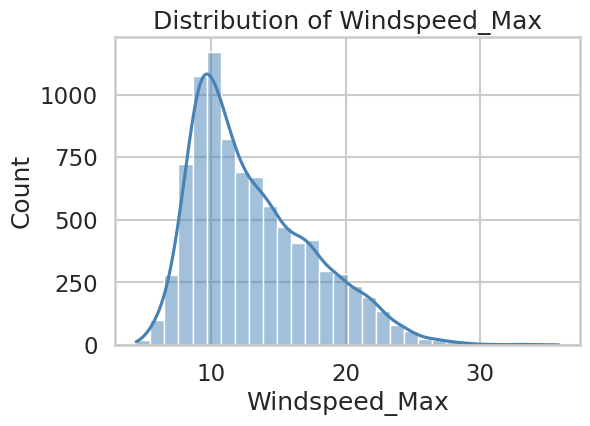

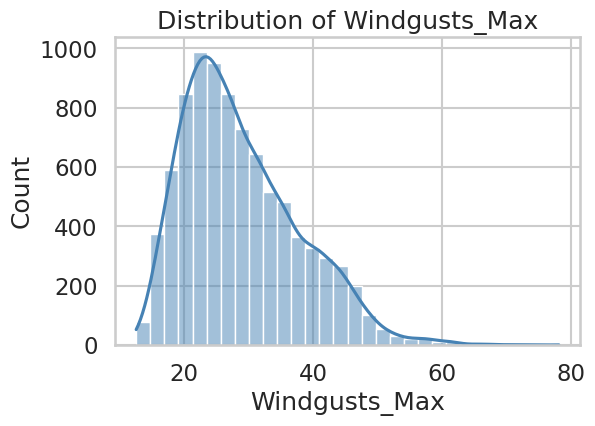

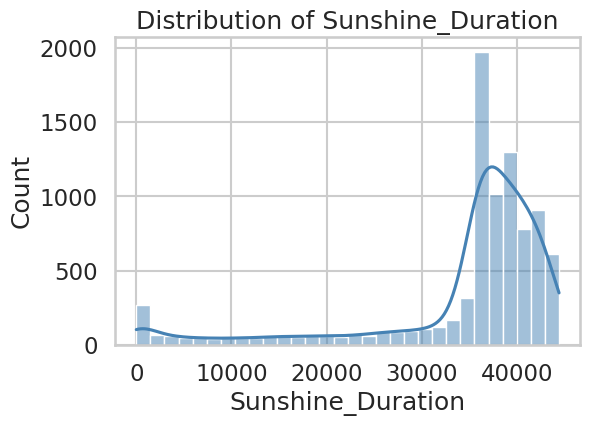

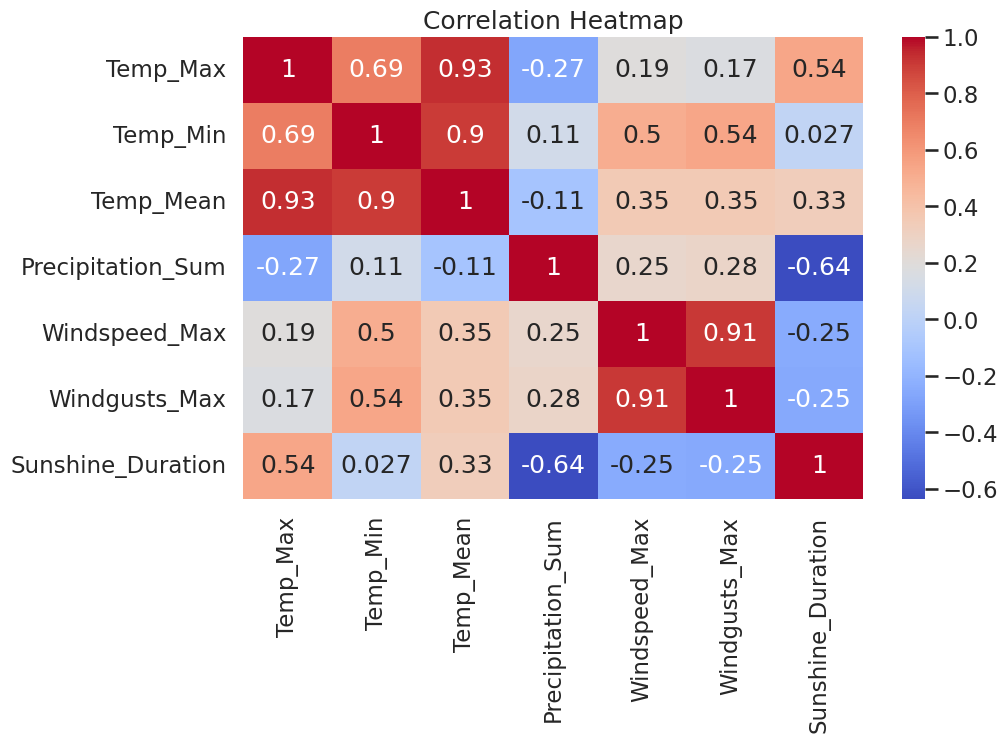


✅ Advanced Weather EDA Completed


In [7]:
# advanced_eda_weather.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_theme(style="whitegrid", palette="Set2", context="talk")

def add_time_features(df, date_col):
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df["year"] = df[date_col].dt.year
    df["month"] = df[date_col].dt.month
    df["dayofweek"] = df[date_col].dt.dayofweek
    df["season"] = df[date_col].dt.month%12 // 3 + 1   # 1=Winter,2=Spring,3=Summer,4=Fall
    return df

def advanced_weather_eda(df, target=None, date_col=None):
    print("\n" + "="*50)
    print("🔎 BASIC INFO")
    print("="*50)
    print(df.info())
    print("\nShape:", df.shape)
    print("\nFirst 5 rows:\n", df.head())

    # Missing values
    print("\n❌ Missing values")
    msno.bar(df)
    plt.show()

    # Add time features if date column present
    if date_col and date_col in df.columns:
        df = add_time_features(df, date_col)
        print("\n📌 Time features created: year, month, dayofweek, season")

    # Numeric and categorical columns
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    # Summary
    print("\n📊 Numerical summary:\n", df[num_cols].describe().T)

    # Distribution plots
    for col in num_cols:
        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True, bins=30, color="steelblue")
        plt.title(f"Distribution of {col}")
        plt.show()

    # Correlation heatmap
    if len(num_cols) > 1:
        plt.figure(figsize=(10,6))
        sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
        plt.title("Correlation Heatmap")
        plt.show()

    # Seasonality plots
    if date_col and "month" in df.columns:
        for col in num_cols:
            if col != "year":
                plt.figure(figsize=(8,4))
                sns.lineplot(x="month", y=col, data=df, estimator="mean", ci=None, marker="o")
                plt.title(f"Monthly Trend of {col}")
                plt.show()

        for col in num_cols:
            plt.figure(figsize=(8,4))
            sns.lineplot(x="year", y=col, data=df, estimator="mean", ci=None, marker="o")
            plt.title(f"Yearly Trend of {col}")
            plt.show()

    # Target analysis
    if target and target in df.columns:
        print(f"\n🎯 Target Analysis vs {target}")
        if target in num_cols:
            plt.figure(figsize=(6,4))
            sns.histplot(df[target], kde=True, color="green")
            plt.title(f"Distribution of target: {target}")
            plt.show()

            # Rolling mean (trend smoothing)
            if date_col and date_col in df.columns:
                plt.figure(figsize=(10,4))
                df.set_index(date_col)[target].rolling(window=30).mean().plot()
                plt.title(f"30-day Rolling Mean of {target}")
                plt.show()

    print("\n✅ Advanced Weather EDA Completed")
    return df

# ----------------------
# Example usage:
# ----------------------
if __name__ == "__main__":
    df = pd.read_csv("/kaggle/input/weather-data2000-2023/India_weather_data.csv")
    df = advanced_weather_eda(df, target="Rainfall", date_col="date")  # change target/date_col as per dataset
